<a href="https://colab.research.google.com/github/FasikuChristian/QSAR-Modeling-Pipeline-for-Serine-Threonine-Kinase-1/blob/main/CDD_ML_Part_2_QSAR_Exploratory_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Bioinformatics Project - Computational Drug Discovery [Part 2] Exploratory Data Analysis**

Credits:
Chanin Nantasenamat(Data Professor) for developing this pipeline


## **Install conda and rdkit**

In [ ]:
#@title **Install Conda Colab**
#@markdown It will restart the kernel (session), don't worry.
# !pip install -q condacolab
# import condacolab
# condacolab.install()
!pip install -q condacolab
import condacolab
condacolab.install_from_url("https://github.com/conda-forge/miniforge/releases/download/25.3.1-0/Miniforge3-Linux-x86_64.sh")


✨🍰✨ Everything looks OK!


In [ ]:
import subprocess
import sys
subprocess.run("pip install rdkit==2025.3.1", shell=True)

CompletedProcess(args='pip install rdkit==2025.3.1', returncode=0)

In [ ]:
from rdkit import Chem
mol = Chem.MolFromSmiles("CCO")
print(Chem.MolToSmiles(mol))

CCO


## Setting Treashold

The bioactivity data is in the IC50 unit. Compounds having values of less than 1000 nM will be considered to be active while those greater than 10,000 nM will be considered to be inactive. As for those values in between 1,000 and 10,000 nM will be referred to as intermediate.

In [ ]:
bioactivity_threshold = []
for i in df4.standard_value:
  if float(i) >= 10000:
    bioactivity_threshold.append("inactive")
  elif float(i) <= 1000:
    bioactivity_threshold.append("active")
  else:
    bioactivity_threshold.append("intermediate")

In [ ]:
bioactivity_class = pd.Series(bioactivity_threshold, name='class')
df5 = pd.concat([df4, bioactivity_class], axis=1)
df5
df5.to_csv('AKT1_03_bioactivity_data_with_class.csv')


In [ ]:
import os

dest_dir = "/content/drive/MyDrive/Colab Notebooks/QSAR MODELLING CODES/AKT1"

# Copy file
! cp AKT1_03_bioactivity_data_with_class.csv "{dest_dir}"

In [ ]:
df = df5

In [ ]:
df_no_smiles = df.drop(columns='canonical_smiles')

In [ ]:
smiles = []

for i in df.canonical_smiles.tolist():
  cpd = str(i).split('.')
  cpd_longest = max(cpd, key = len)
  smiles.append(cpd_longest)

smiles = pd.Series(smiles, name = 'canonical_smiles')

In [ ]:
df_clean_smiles = pd.concat([df_no_smiles,smiles], axis=1)
df_clean_smiles

,molecule_chembl_id,standard_value,class,canonical_smiles
0,CHEMBL281872,20000.0,inactive,COc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCn1ccnn1
1,CHEMBL533849,20000.0,inactive,COc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCC1CCN(C)CC1
2,CHEMBL414139,1000.0,active,COc1cc2c(Nc3ccc(Oc4ccccc4)cc3)c(C#N)cnc2cc1OCC...
3,CHEMBL318804,1000.0,active,COc1cc2c(Nc3ccc(Sc4nccn4C)c(Cl)c3)c(C#N)cnc2cc...
4,CHEMBL2368948,1500.0,intermediate,CCCCCCCCCCCCCCCCCCOC[C@H](COP(=O)(O)O[C@H]1[C@...
...,...,...,...,...
150,CHEMBL595583,10000.0,inactive,CCCCCCCCCCCCc1ccc(S(=O)(=O)Nc2nncs2)cc1
151,CHEMBL1186409,2834.9,intermediate,CC[n+]1c(/C=C/N(C)c2ccccc2)n(-c2ccccc2)c2ccc(-...
152,CHEMBL379218,3236.9,intermediate,Cc1n[nH]c2ccc(-c3cncc(OC[C@@H](N)Cc4ccccc4)c3)...
153,CHEMBL494089,10000.0,inactive,CCn1c(-c2nonc2N)nc2c(C#CC(C)(C)O)ncc(OC[C@H]3C...


## **Calculate Lipinski descriptors**
Christopher Lipinski, a scientist at Pfizer, came up with a set of rule-of-thumb for evaluating the **druglikeness** of compounds. Such druglikeness is based on the Absorption, Distribution, Metabolism and Excretion (ADME) that is also known as the pharmacokinetic profile. Lipinski analyzed all orally active FDA-approved drugs in the formulation of what is to be known as the **Rule-of-Five** or **Lipinski's Rule**.

The Lipinski's Rule stated the following:
* Molecular weight < 500 Dalton
* Octanol-water partition coefficient (LogP) < 5
* Hydrogen bond donors < 5
* Hydrogen bond acceptors < 10

### **Import libraries**

In [ ]:
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski

### **Calculate descriptors**

In [ ]:
# Inspired by: https://codeocean.com/explore/capsules?query=tag:data-curation

def lipinski(smiles, verbose=False):

    moldata= []
    for elem in smiles:
        mol=Chem.MolFromSmiles(elem)
        moldata.append(mol)

    baseData= np.arange(1,1)
    i=0
    for mol in moldata:

        desc_MolWt = Descriptors.MolWt(mol)
        desc_MolLogP = Descriptors.MolLogP(mol)
        desc_NumHDonors = Lipinski.NumHDonors(mol)
        desc_NumHAcceptors = Lipinski.NumHAcceptors(mol)

        row = np.array([desc_MolWt,
                        desc_MolLogP,
                        desc_NumHDonors,
                        desc_NumHAcceptors])

        if(i==0):
            baseData=row
        else:
            baseData=np.vstack([baseData, row])
        i=i+1

    columnNames=["MW","LogP","NumHDonors","NumHAcceptors"]
    descriptors = pd.DataFrame(data=baseData,columns=columnNames)

    return descriptors

In [ ]:
df_lipinski = lipinski(df_clean_smiles.canonical_smiles)
df_lipinski

,MW,LogP,NumHDonors,NumHAcceptors
0,459.279,3.95410,1.0,8.0
1,475.362,5.00420,1.0,6.0
2,510.594,5.75208,1.0,8.0
3,565.099,5.49788,1.0,10.0
4,584.728,4.62900,5.0,9.0
...,...,...,...,...
150,409.621,5.80230,1.0,5.0
151,487.652,7.32170,0.0,4.0
152,358.445,3.88212,2.0,4.0
153,425.493,1.58420,3.0,10.0


### **Combine DataFrames**

Let's take a look at the 2 DataFrames that will be combined.

In [ ]:
df_lipinski

,MW,LogP,NumHDonors,NumHAcceptors
0,459.279,3.95410,1.0,8.0
1,475.362,5.00420,1.0,6.0
2,510.594,5.75208,1.0,8.0
3,565.099,5.49788,1.0,10.0
4,584.728,4.62900,5.0,9.0
...,...,...,...,...
150,409.621,5.80230,1.0,5.0
151,487.652,7.32170,0.0,4.0
152,358.445,3.88212,2.0,4.0
153,425.493,1.58420,3.0,10.0


In [ ]:
df

,molecule_chembl_id,canonical_smiles,standard_value,class
0,CHEMBL281872,COc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCn1ccnn1,20000.0,inactive
1,CHEMBL533849,COc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCC1CCN(C)CC1.Cl,20000.0,inactive
2,CHEMBL414139,COc1cc2c(Nc3ccc(Oc4ccccc4)cc3)c(C#N)cnc2cc1OCC...,1000.0,active
3,CHEMBL318804,COc1cc2c(Nc3ccc(Sc4nccn4C)c(Cl)c3)c(C#N)cnc2cc...,1000.0,active
4,CHEMBL2368948,CCCCCCCCCCCCCCCCCCOC[C@H](COP(=O)(O)O[C@H]1[C@...,1500.0,intermediate
...,...,...,...,...
150,CHEMBL595583,CCCCCCCCCCCCc1ccc(S(=O)(=O)Nc2nncs2)cc1,10000.0,inactive
151,CHEMBL1186409,CC[n+]1c(/C=C/N(C)c2ccccc2)n(-c2ccccc2)c2ccc(-...,2834.9,intermediate
152,CHEMBL379218,Cc1n[nH]c2ccc(-c3cncc(OC[C@@H](N)Cc4ccccc4)c3)...,3236.9,intermediate
153,CHEMBL494089,CCn1c(-c2nonc2N)nc2c(C#CC(C)(C)O)ncc(OC[C@H]3C...,10000.0,inactive


Now, let's combine the 2 DataFrame

In [ ]:
df_combined = pd.concat([df,df_lipinski], axis=1)

In [ ]:
df_combined

,molecule_chembl_id,canonical_smiles,standard_value,class,MW,LogP,NumHDonors,NumHAcceptors
0,CHEMBL281872,COc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCn1ccnn1,20000.0,inactive,459.279,3.95410,1.0,8.0
1,CHEMBL533849,COc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCC1CCN(C)CC1.Cl,20000.0,inactive,475.362,5.00420,1.0,6.0
2,CHEMBL414139,COc1cc2c(Nc3ccc(Oc4ccccc4)cc3)c(C#N)cnc2cc1OCC...,1000.0,active,510.594,5.75208,1.0,8.0
3,CHEMBL318804,COc1cc2c(Nc3ccc(Sc4nccn4C)c(Cl)c3)c(C#N)cnc2cc...,1000.0,active,565.099,5.49788,1.0,10.0
4,CHEMBL2368948,CCCCCCCCCCCCCCCCCCOC[C@H](COP(=O)(O)O[C@H]1[C@...,1500.0,intermediate,584.728,4.62900,5.0,9.0
...,...,...,...,...,...,...,...,...
150,CHEMBL595583,CCCCCCCCCCCCc1ccc(S(=O)(=O)Nc2nncs2)cc1,10000.0,inactive,409.621,5.80230,1.0,5.0
151,CHEMBL1186409,CC[n+]1c(/C=C/N(C)c2ccccc2)n(-c2ccccc2)c2ccc(-...,2834.9,intermediate,487.652,7.32170,0.0,4.0
152,CHEMBL379218,Cc1n[nH]c2ccc(-c3cncc(OC[C@@H](N)Cc4ccccc4)c3)...,3236.9,intermediate,358.445,3.88212,2.0,4.0
153,CHEMBL494089,CCn1c(-c2nonc2N)nc2c(C#CC(C)(C)O)ncc(OC[C@H]3C...,10000.0,inactive,425.493,1.58420,3.0,10.0


### **Convert IC50 to pIC50**
To allow **IC50** data to be more uniformly distributed, we will convert **IC50** to the negative logarithmic scale which is essentially **-log10(IC50)**.

This custom function pIC50() will accept a DataFrame as input and will:
* Take the IC50 values from the ``standard_value`` column and converts it from nM to M by multiplying the value by 10$^{-9}$
* Take the molar value and apply -log10
* Delete the ``standard_value`` column and create a new ``pIC50`` column

In [ ]:
import numpy as np

def pIC50(input):
    pIC50 = []

    for i in input['standard_value_norm']:
        molar = i*(10**-9) # Converts nM to M
        pIC50.append(-np.log10(molar))

    input['pIC50'] = pIC50
    x = input.drop('standard_value_norm', 1)

    return x

Point to note: Values greater than 100,000,000 will be fixed at 100,000,000 otherwise the negative logarithmic value will become negative.

In [ ]:
df_combined.standard_value.describe()

,standard_value
count,155.000000
mean,5406.313355
std,9413.971507
min,0.200000
25%,25.500000
50%,1000.000000
75%,10000.000000
max,50000.000000


In [ ]:
df_combined

,molecule_chembl_id,canonical_smiles,standard_value,class,MW,LogP,NumHDonors,NumHAcceptors
0,CHEMBL281872,COc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCn1ccnn1,20000.0,inactive,459.279,3.95410,1.0,8.0
1,CHEMBL533849,COc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCC1CCN(C)CC1.Cl,20000.0,inactive,475.362,5.00420,1.0,6.0
2,CHEMBL414139,COc1cc2c(Nc3ccc(Oc4ccccc4)cc3)c(C#N)cnc2cc1OCC...,1000.0,active,510.594,5.75208,1.0,8.0
3,CHEMBL318804,COc1cc2c(Nc3ccc(Sc4nccn4C)c(Cl)c3)c(C#N)cnc2cc...,1000.0,active,565.099,5.49788,1.0,10.0
4,CHEMBL2368948,CCCCCCCCCCCCCCCCCCOC[C@H](COP(=O)(O)O[C@H]1[C@...,1500.0,intermediate,584.728,4.62900,5.0,9.0
...,...,...,...,...,...,...,...,...
150,CHEMBL595583,CCCCCCCCCCCCc1ccc(S(=O)(=O)Nc2nncs2)cc1,10000.0,inactive,409.621,5.80230,1.0,5.0
151,CHEMBL1186409,CC[n+]1c(/C=C/N(C)c2ccccc2)n(-c2ccccc2)c2ccc(-...,2834.9,intermediate,487.652,7.32170,0.0,4.0
152,CHEMBL379218,Cc1n[nH]c2ccc(-c3cncc(OC[C@@H](N)Cc4ccccc4)c3)...,3236.9,intermediate,358.445,3.88212,2.0,4.0
153,CHEMBL494089,CCn1c(-c2nonc2N)nc2c(C#CC(C)(C)O)ncc(OC[C@H]3C...,10000.0,inactive,425.493,1.58420,3.0,10.0


In [ ]:
-np.log10( (10**-9)* 100000000 )

np.float64(1.0)

In [ ]:
-np.log10( (10**-9)* 10000000000 )

np.float64(-1.0)

In [ ]:
def norm_value(input):
    norm = []

    for i in input['standard_value']:
        if i > 100000000:
          i = 100000000
        norm.append(i)

    input['standard_value_norm'] = norm
    x = input.drop('standard_value', 1)

    return x

We will first apply the norm_value() function so that the values in the standard_value column is normalized.

In [ ]:
def norm_value(input):
    norm = []

    for i in input['standard_value']:
        if i > 100000000:
          i = 100000000
        norm.append(i)

    input['standard_value_norm'] = norm
    # Fix: explicitly use axis=1 for dropping the column
    x = input.drop('standard_value', axis=1)

    return x

df_norm = norm_value(df_combined)
df_norm

,molecule_chembl_id,canonical_smiles,class,MW,LogP,NumHDonors,NumHAcceptors,standard_value_norm
0,CHEMBL281872,COc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCn1ccnn1,inactive,459.279,3.95410,1.0,8.0,20000.0
1,CHEMBL533849,COc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCC1CCN(C)CC1.Cl,inactive,475.362,5.00420,1.0,6.0,20000.0
2,CHEMBL414139,COc1cc2c(Nc3ccc(Oc4ccccc4)cc3)c(C#N)cnc2cc1OCC...,active,510.594,5.75208,1.0,8.0,1000.0
3,CHEMBL318804,COc1cc2c(Nc3ccc(Sc4nccn4C)c(Cl)c3)c(C#N)cnc2cc...,active,565.099,5.49788,1.0,10.0,1000.0
4,CHEMBL2368948,CCCCCCCCCCCCCCCCCCOC[C@H](COP(=O)(O)O[C@H]1[C@...,intermediate,584.728,4.62900,5.0,9.0,1500.0
...,...,...,...,...,...,...,...,...
150,CHEMBL595583,CCCCCCCCCCCCc1ccc(S(=O)(=O)Nc2nncs2)cc1,inactive,409.621,5.80230,1.0,5.0,10000.0
151,CHEMBL1186409,CC[n+]1c(/C=C/N(C)c2ccccc2)n(-c2ccccc2)c2ccc(-...,intermediate,487.652,7.32170,0.0,4.0,2834.9
152,CHEMBL379218,Cc1n[nH]c2ccc(-c3cncc(OC[C@@H](N)Cc4ccccc4)c3)...,intermediate,358.445,3.88212,2.0,4.0,3236.9
153,CHEMBL494089,CCn1c(-c2nonc2N)nc2c(C#CC(C)(C)O)ncc(OC[C@H]3C...,inactive,425.493,1.58420,3.0,10.0,10000.0


In [ ]:
df_norm.standard_value_norm.describe()

,standard_value_norm
count,155.000000
mean,5406.313355
std,9413.971507
min,0.200000
25%,25.500000
50%,1000.000000
75%,10000.000000
max,50000.000000


In [ ]:
import numpy as np

def pIC50(input):
    pIC50_list = [] # Renamed to avoid conflict with function name

    for i in input['standard_value_norm']:
        molar = i*(10**-9) # Converts nM to M
        pIC50_list.append(-np.log10(molar))

    input['pIC50'] = pIC50_list
    # Fix: explicitly use axis=1 for dropping the column
    x = input.drop('standard_value_norm', axis=1)

    return x

df_final = pIC50(df_norm)
df_final

,molecule_chembl_id,canonical_smiles,class,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,CHEMBL281872,COc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCn1ccnn1,inactive,459.279,3.95410,1.0,8.0,4.698970
1,CHEMBL533849,COc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCC1CCN(C)CC1.Cl,inactive,475.362,5.00420,1.0,6.0,4.698970
2,CHEMBL414139,COc1cc2c(Nc3ccc(Oc4ccccc4)cc3)c(C#N)cnc2cc1OCC...,active,510.594,5.75208,1.0,8.0,6.000000
3,CHEMBL318804,COc1cc2c(Nc3ccc(Sc4nccn4C)c(Cl)c3)c(C#N)cnc2cc...,active,565.099,5.49788,1.0,10.0,6.000000
4,CHEMBL2368948,CCCCCCCCCCCCCCCCCCOC[C@H](COP(=O)(O)O[C@H]1[C@...,intermediate,584.728,4.62900,5.0,9.0,5.823909
...,...,...,...,...,...,...,...,...
150,CHEMBL595583,CCCCCCCCCCCCc1ccc(S(=O)(=O)Nc2nncs2)cc1,inactive,409.621,5.80230,1.0,5.0,5.000000
151,CHEMBL1186409,CC[n+]1c(/C=C/N(C)c2ccccc2)n(-c2ccccc2)c2ccc(-...,intermediate,487.652,7.32170,0.0,4.0,5.547462
152,CHEMBL379218,Cc1n[nH]c2ccc(-c3cncc(OC[C@@H](N)Cc4ccccc4)c3)...,intermediate,358.445,3.88212,2.0,4.0,5.489871
153,CHEMBL494089,CCn1c(-c2nonc2N)nc2c(C#CC(C)(C)O)ncc(OC[C@H]3C...,inactive,425.493,1.58420,3.0,10.0,5.000000


In [ ]:
df_final.pIC50.describe()

,pIC50
count,155.000000
mean,6.316255
std,1.389541
min,4.301030
25%,5.000000
50%,6.000000
75%,7.595557
max,9.698970


Let's write this to CSV file.

In [ ]:
df_final.to_csv('AKT1_04_bioactivity_data_3class_pIC50_all.csv')
import os

dest_dir = "/content/drive/MyDrive/Colab Notebooks/QSAR MODELLING CODES/AKT1"

# Copy file
! cp /content/AKT1_04_bioactivity_data_3class_pIC50_all.csv "{dest_dir}"

### **Removing the 'intermediate' bioactivity class**
Here, we will be removing the ``intermediate`` class from our data set.

In [ ]:

df_final

,molecule_chembl_id,canonical_smiles,class,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,CHEMBL281872,COc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCn1ccnn1,inactive,459.279,3.95410,1.0,8.0,4.698970
1,CHEMBL533849,COc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCC1CCN(C)CC1.Cl,inactive,475.362,5.00420,1.0,6.0,4.698970
2,CHEMBL414139,COc1cc2c(Nc3ccc(Oc4ccccc4)cc3)c(C#N)cnc2cc1OCC...,active,510.594,5.75208,1.0,8.0,6.000000
3,CHEMBL318804,COc1cc2c(Nc3ccc(Sc4nccn4C)c(Cl)c3)c(C#N)cnc2cc...,active,565.099,5.49788,1.0,10.0,6.000000
4,CHEMBL2368948,CCCCCCCCCCCCCCCCCCOC[C@H](COP(=O)(O)O[C@H]1[C@...,intermediate,584.728,4.62900,5.0,9.0,5.823909
...,...,...,...,...,...,...,...,...
150,CHEMBL595583,CCCCCCCCCCCCc1ccc(S(=O)(=O)Nc2nncs2)cc1,inactive,409.621,5.80230,1.0,5.0,5.000000
151,CHEMBL1186409,CC[n+]1c(/C=C/N(C)c2ccccc2)n(-c2ccccc2)c2ccc(-...,intermediate,487.652,7.32170,0.0,4.0,5.547462
152,CHEMBL379218,Cc1n[nH]c2ccc(-c3cncc(OC[C@@H](N)Cc4ccccc4)c3)...,intermediate,358.445,3.88212,2.0,4.0,5.489871
153,CHEMBL494089,CCn1c(-c2nonc2N)nc2c(C#CC(C)(C)O)ncc(OC[C@H]3C...,inactive,425.493,1.58420,3.0,10.0,5.000000


In [ ]:
df_2class = df_final[df_final['class'] != 'intermediate']
df_2class

,molecule_chembl_id,canonical_smiles,class,MW,LogP,NumHDonors,NumHAcceptors,pIC50
0,CHEMBL281872,COc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCCn1ccnn1,inactive,459.279,3.95410,1.0,8.0,4.698970
1,CHEMBL533849,COc1cc2c(Nc3ccc(Br)cc3F)ncnc2cc1OCC1CCN(C)CC1.Cl,inactive,475.362,5.00420,1.0,6.0,4.698970
2,CHEMBL414139,COc1cc2c(Nc3ccc(Oc4ccccc4)cc3)c(C#N)cnc2cc1OCC...,active,510.594,5.75208,1.0,8.0,6.000000
3,CHEMBL318804,COc1cc2c(Nc3ccc(Sc4nccn4C)c(Cl)c3)c(C#N)cnc2cc...,active,565.099,5.49788,1.0,10.0,6.000000
7,CHEMBL2368953,CCCCCCCCCCCCCCCCCCOC[C@H](COC(=O)O[C@@H]1[C@H]...,inactive,578.784,3.86700,5.0,10.0,4.494850
...,...,...,...,...,...,...,...,...
147,CHEMBL1186409,CC[n+]1c(/C=C/N(C)c2ccccc2)n(-c2ccccc2)c2ccc(-...,active,487.652,7.32170,0.0,4.0,6.699839
149,CHEMBL494089,CCn1c(-c2nonc2N)nc2c(C#CC(C)(C)O)ncc(OC[C@H]3C...,inactive,425.493,1.58420,3.0,10.0,5.000000
150,CHEMBL595583,CCCCCCCCCCCCc1ccc(S(=O)(=O)Nc2nncs2)cc1,inactive,409.621,5.80230,1.0,5.0,5.000000
153,CHEMBL494089,CCn1c(-c2nonc2N)nc2c(C#CC(C)(C)O)ncc(OC[C@H]3C...,inactive,425.493,1.58420,3.0,10.0,5.000000


Let's write this to CSV file.

In [ ]:
df_2class.to_csv('AKT_05_bioactivity_data_2class_nointermediate_pIC50.csv')


In [ ]:
import os

dest_dir = "/content/drive/MyDrive/Colab Notebooks/QSAR MODELLING CODES/AKT1"

# Copy file
! cp /content/AKT_05_bioactivity_data_2class_nointermediate_pIC50.csv "{dest_dir}"

---

## **Exploratory Data Analysis (Chemical Space Analysis) via Lipinski descriptors**

### **Import library**

In [ ]:
import seaborn as sns
sns.set(style='ticks')
import matplotlib.pyplot as plt

### **Frequency plot of the 2 bioactivity classes**

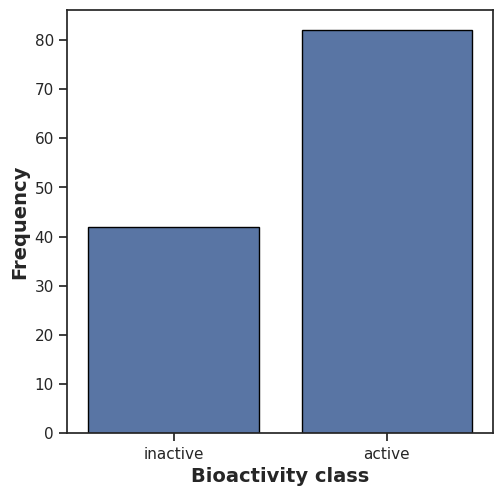

In [ ]:
plt.figure(figsize=(5.5, 5.5))

sns.countplot(x='class', data=df_2class, edgecolor='black')

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')

plt.savefig('plot_bioactivity_class.pdf')

### **Scatter plot of MW versus LogP**

It can be seen that the 2 bioactivity classes are spanning similar chemical spaces as evident by the scatter plot of MW vs LogP.

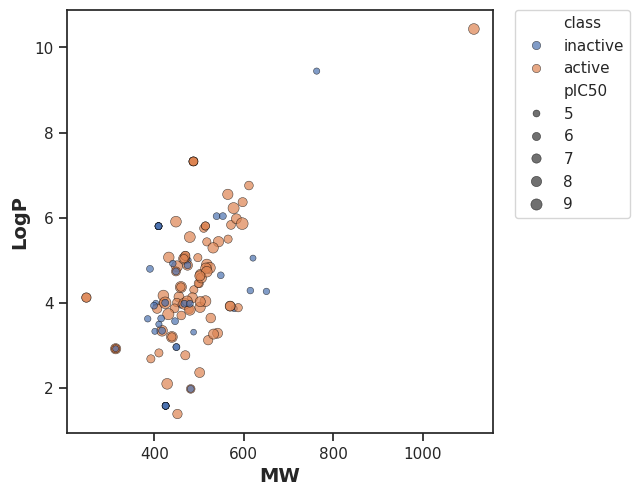

In [ ]:
plt.figure(figsize=(5.5, 5.5))

sns.scatterplot(x='MW', y='LogP', data=df_2class, hue='class', size='pIC50', edgecolor='black', alpha=0.7)

plt.xlabel('MW', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0)
plt.savefig('plot_MW_vs_LogP.pdf')

### **Box plots**

#### **pIC50 value**

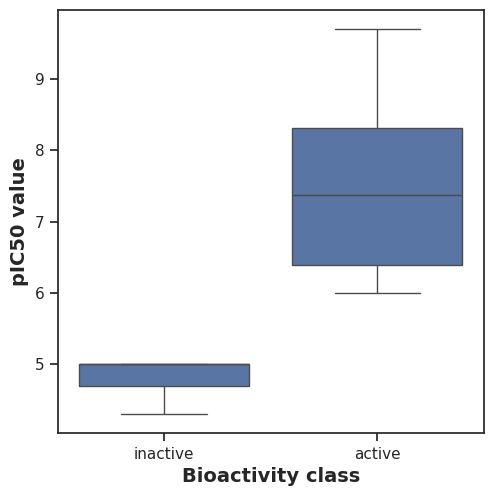

In [ ]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'class', y = 'pIC50', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('pIC50 value', fontsize=14, fontweight='bold')

plt.savefig('plot_ic50.pdf')

**Statistical analysis | Mann-Whitney U Test**

In [ ]:
def mannwhitney(descriptor, verbose=False):
  # https://machinelearningmastery.com/nonparametric-statistical-significance-tests-in-python/
  from numpy.random import seed
  from numpy.random import randn
  from scipy.stats import mannwhitneyu

# seed the random number generator
  seed(1)

# actives and inactives
  selection = [descriptor, 'class']
  df = df_2class[selection]
  active = df[df['class'] == 'active']
  active = active[descriptor]

  selection = [descriptor, 'class']
  df = df_2class[selection]
  inactive = df[df['class'] == 'inactive']
  inactive = inactive[descriptor]

# compare samples
  stat, p = mannwhitneyu(active, inactive)
  #print('Statistics=%.3f, p=%.3f' % (stat, p))

# interpret
  alpha = 0.05
  if p > alpha:
    interpretation = 'Same distribution (fail to reject H0)'
  else:
    interpretation = 'Different distribution (reject H0)'

  results = pd.DataFrame({'Descriptor':descriptor,
                          'Statistics':stat,
                          'p':p,
                          'alpha':alpha,
                          'Interpretation':interpretation}, index=[0])
  filename = 'mannwhitneyu_' + descriptor + '.csv'
  results.to_csv(filename)

  return results

In [ ]:
mannwhitney('pIC50')

,Descriptor,Statistics,p,alpha,Interpretation
0,pIC50,3444.0,6.838676e-20,0.05,Different distribution (reject H0)


#### **MW**

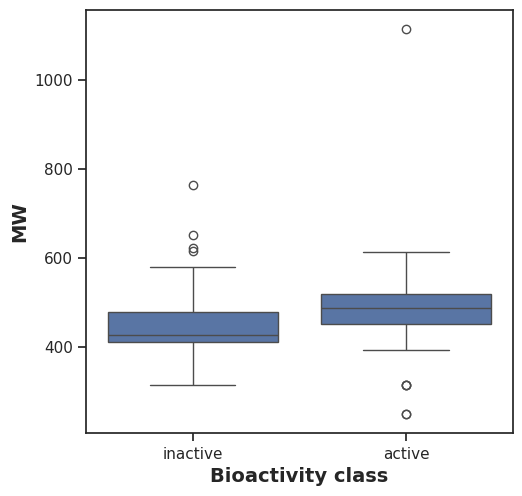

In [ ]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'class', y = 'MW', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('MW', fontsize=14, fontweight='bold')

plt.savefig('plot_MW.pdf')

In [ ]:
mannwhitney('MW')

,Descriptor,Statistics,p,alpha,Interpretation
0,MW,2317.5,0.001678,0.05,Different distribution (reject H0)


#### **LogP**

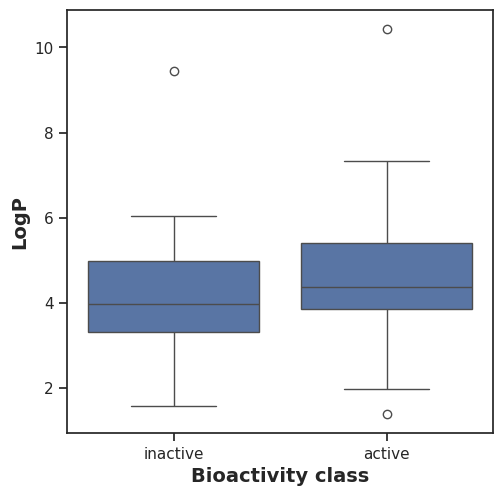

In [ ]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'class', y = 'LogP', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('LogP', fontsize=14, fontweight='bold')

plt.savefig('plot_LogP.pdf')

**Statistical analysis | Mann-Whitney U Test**

In [ ]:
mannwhitney('LogP')

,Descriptor,Statistics,p,alpha,Interpretation
0,LogP,2051.0,0.082798,0.05,Same distribution (fail to reject H0)


#### **NumHDonors**

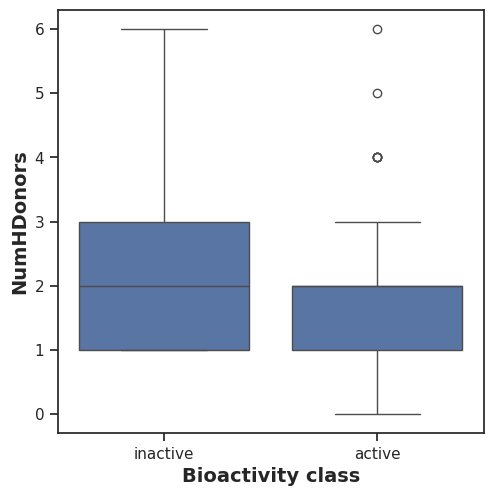

In [ ]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'class', y = 'NumHDonors', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHDonors', fontsize=14, fontweight='bold')

plt.savefig('plot_NumHDonors.pdf')

**Statistical analysis | Mann-Whitney U Test**

In [ ]:
mannwhitney('NumHDonors')

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHDonors,1334.0,0.032274,0.05,Different distribution (reject H0)


#### **NumHAcceptors**

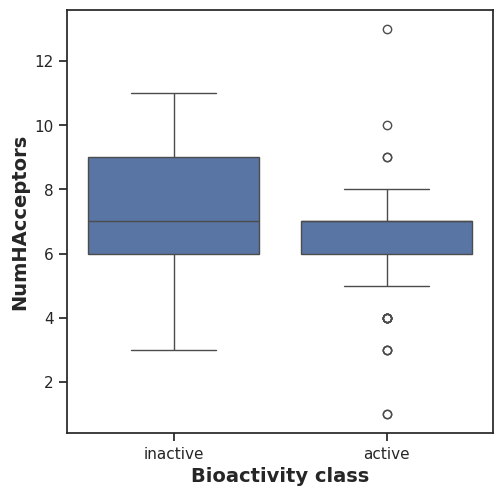

In [ ]:
plt.figure(figsize=(5.5, 5.5))

sns.boxplot(x = 'class', y = 'NumHAcceptors', data = df_2class)

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('NumHAcceptors', fontsize=14, fontweight='bold')

plt.savefig('plot_NumHAcceptors.pdf')

In [ ]:
mannwhitney('NumHAcceptors')

,Descriptor,Statistics,p,alpha,Interpretation
0,NumHAcceptors,1235.5,0.008696,0.05,Different distribution (reject H0)


#### **Interpretation of Statistical Results**

## **Zip files**

In [ ]:
! zip -r Statistics_results.zip . -i *.csv *.pdf

updating: AKT1_03_bioactivity_data_with_class.csv (deflated 81%)
updating: plot_LogP.pdf (deflated 37%)
updating: plot_MW.pdf (deflated 40%)
updating: plot_NumHDonors.pdf (deflated 37%)
updating: AKT_05_bioactivity_data_2class_nointermediate_pIC50.csv (deflated 76%)
updating: AKT1_04_bioactivity_data_3class_pIC50_all.csv (deflated 78%)
updating: mannwhitneyu_pIC50.csv (deflated 10%)
updating: plot_MW_vs_LogP.pdf (deflated 14%)
updating: plot_ic50.pdf (deflated 37%)
updating: mannwhitneyu_LogP.csv (deflated 9%)
updating: mannwhitneyu_NumHDonors.csv (deflated 10%)
updating: mannwhitneyu_NumHAcceptors.csv (deflated 11%)
updating: plot_bioactivity_class.pdf (deflated 37%)
updating: mannwhitneyu_MW.csv (deflated 8%)
updating: plot_NumHAcceptors.pdf (deflated 37%)


In [ ]:
import os

dest_dir = "/content/drive/MyDrive/Colab Notebooks/QSAR MODELLING CODES/AKT1"

# Copy file
! cp /content/Statistics_results.zip "{dest_dir}"